# Report 3 — Top Performing Restaurants & Rating Correlation
Data source: `restaurant_performance.csv`

**Columns:** `restaurant_name`, `category`, `halal_status`, `rating`, `location_area`, `yr_quarter`, `order_count`, `total_revenue`, `avg_order_value`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os

%matplotlib inline

## Load and clean data

In [2]:
CSV = os.path.join(os.getcwd(), "restaurant_performance.csv")

df = pd.read_csv(CSV, header=0, names=[
    "restaurant_name", "category", "halal_status", "rating", "location_area",
    "yr_quarter", "order_count", "total_revenue", "avg_order_value"
])
df["order_count"] = pd.to_numeric(df["order_count"], errors="coerce")
df["total_revenue"] = pd.to_numeric(df["total_revenue"], errors="coerce")
df["avg_order_value"] = pd.to_numeric(df["avg_order_value"], errors="coerce")
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

# Rating tiers
df["rating_tier"] = pd.cut(df["rating"], bins=[0, 3, 4, 5.01],
                            labels=["Low (0-2.99)", "Mid (3-3.99)", "High (4-5)"],
                            right=False)

TIER_COLORS = {"Low (0-2.99)": "#E74C3C", "Mid (3-3.99)": "#F39C12", "High (4-5)": "#2ECC71"}

df.head()

,restaurant_name,category,halal_status,rating,location_area,yr_quarter,order_count,total_revenue,avg_order_value,rating_tier
0,Banana Leaf Junction,Indian Cuisine,HALAL,4.4,Brickfields,2016-Q2,1,103.60,103.60,High (4-5)
1,Banana Leaf Junction,Indian Cuisine,HALAL,4.4,Brickfields,2016-Q3,4,487.88,121.97,High (4-5)
2,Banana Leaf Junction,Indian Cuisine,HALAL,4.4,Brickfields,2017-Q1,1,96.00,96.00,High (4-5)
3,Banana Leaf Junction,Indian Cuisine,HALAL,4.4,Brickfields,2017-Q2,1,79.50,79.50,High (4-5)
4,Banana Leaf Junction,Indian Cuisine,HALAL,4.4,Brickfields,2017-Q4,1,79.50,79.50,High (4-5)


## VIZ 1 — Rating vs Total Revenue (bubble = order count)
### Pattern: does higher rating correlate with higher revenue?

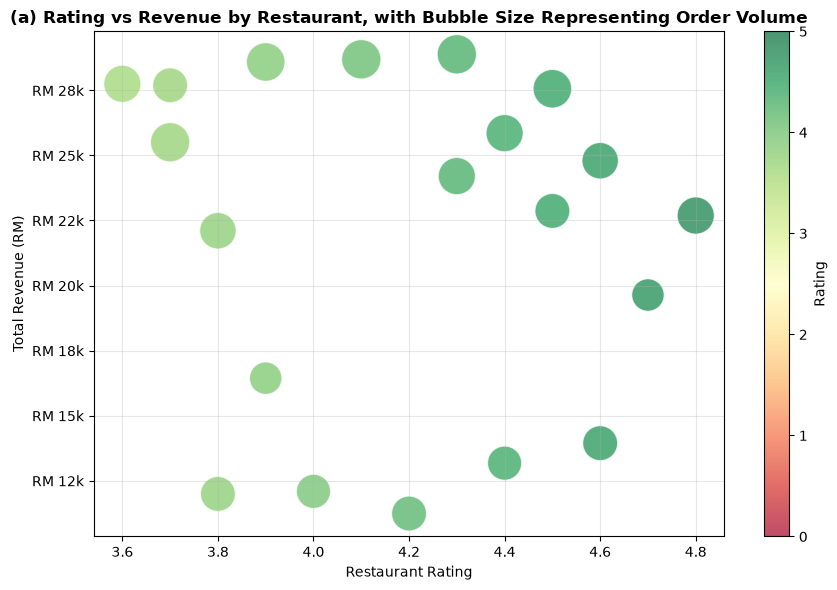

In [3]:
fig1, ax1 = plt.subplots(figsize=(9, 6))
rest_agg = df.groupby(["restaurant_name", "rating"]).agg(
    total_revenue=("total_revenue", "sum"),
    order_count=("order_count", "sum")
).reset_index()

bubble = (rest_agg["order_count"] / rest_agg["order_count"].max()) * 800
scatter = ax1.scatter(
    rest_agg["rating"], rest_agg["total_revenue"],
    s=bubble, c=rest_agg["rating"], cmap="RdYlGn",
    vmin=0, vmax=5, alpha=0.7, edgecolors="white", linewidths=0.8
)
plt.colorbar(scatter, ax=ax1, label="Rating")
ax1.set_xlabel("Restaurant Rating")
ax1.set_ylabel("Total Revenue (RM)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'RM {x/1000:.0f}k'))
ax1.set_title(
    "(a) Rating vs Revenue by Restaurant, with Bubble Size Representing Order Volume",
    fontweight="bold"
)
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## VIZ 2 — Quarterly Revenue by Restaurant Rating Tier
### Pattern: high-rated restaurants' revenue share over time

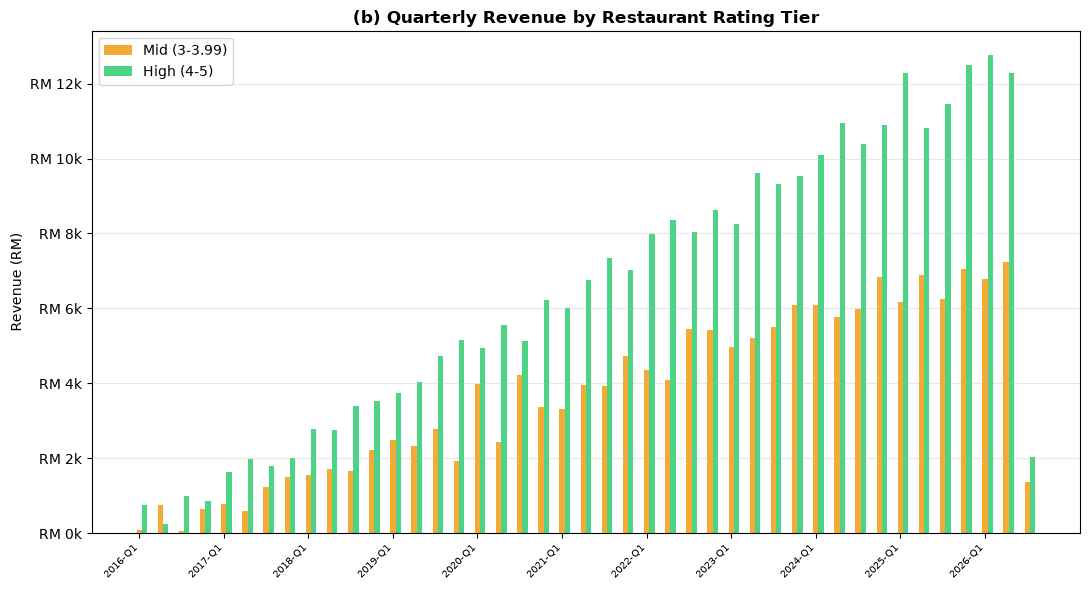

In [4]:
fig2, ax2 = plt.subplots(figsize=(11, 6))
grp2 = df.groupby(["yr_quarter", "rating_tier"])["total_revenue"].sum().unstack(fill_value=0)
quarters = grp2.index.tolist()
x = np.arange(len(quarters))
w = 0.25

for i, tier in enumerate(["Low (0-2.99)", "Mid (3-3.99)", "High (4-5)"]):
    if tier in grp2.columns:
        ax2.bar(x + i * w, grp2[tier], w, label=tier,
                color=TIER_COLORS.get(tier, "grey"), alpha=0.85)

step2 = max(1, len(quarters) // 10)
ax2.set_xticks(x[::step2] + w)
ax2.set_xticklabels([quarters[i] for i in range(0, len(quarters), step2)],
                     rotation=45, ha="right", fontsize=7)
ax2.set_ylabel("Revenue (RM)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'RM {x/1000:.0f}k'))
ax2.set_title(
    "(b) Quarterly Revenue by Restaurant Rating Tier",
    fontweight="bold"
)
ax2.legend()
ax2.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## VIZ 3 — Top 10 Restaurants by Revenue
### Pattern: which restaurants dominate platform revenue

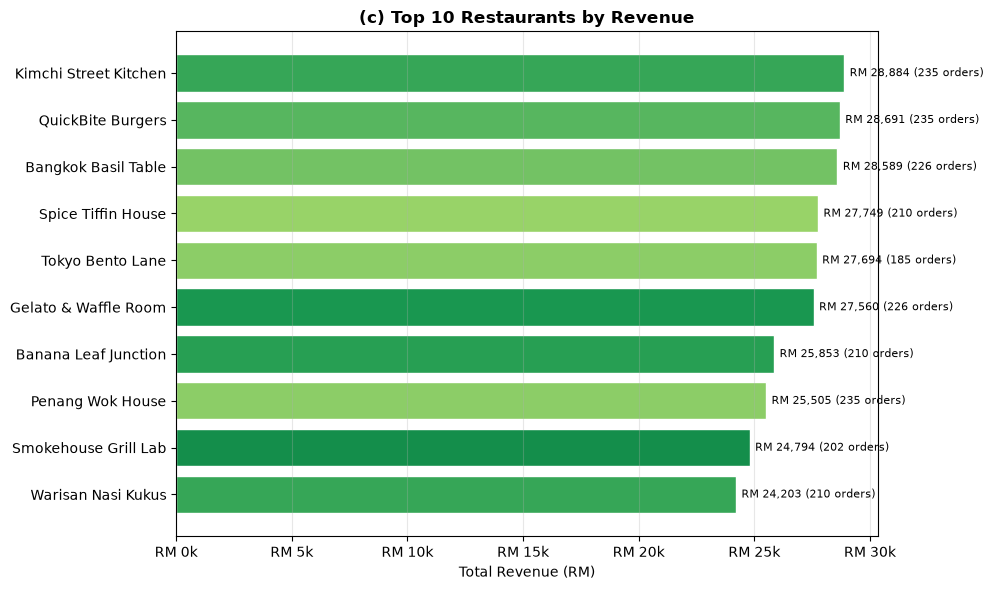

In [5]:
fig3, ax3 = plt.subplots(figsize=(10, 6))
top10 = rest_agg.nlargest(10, "total_revenue")
colors3 = plt.cm.RdYlGn(top10["rating"] / 5.0)
bars = ax3.barh(top10["restaurant_name"], top10["total_revenue"],
                color=colors3, edgecolor="white")
ax3.set_xlabel("Total Revenue (RM)")
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'RM {x/1000:.0f}k'))
ax3.set_title(
    "(c) Top 10 Restaurants by Revenue",
    fontweight="bold"
)
ax3.invert_yaxis()
ax3.grid(axis="x", alpha=0.3)

labels = [f"RM {rev:,.0f} ({cnt:.0f} orders)" for rev, cnt in zip(top10["total_revenue"], top10["order_count"])]
ax3.bar_label(bars, labels=labels, padding=4, fontsize=8)
plt.tight_layout()
plt.show()

## VIZ 4 — Average Order Value Distribution by Rating Tier
### Pattern: do higher-rated restaurants command higher basket sizes?

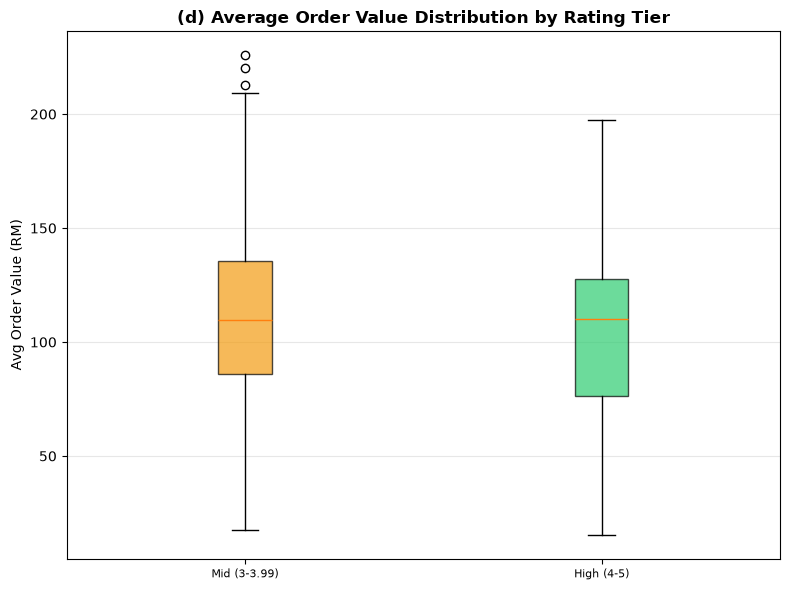

In [6]:
fig4, ax4 = plt.subplots(figsize=(8, 6))
tiers_present = [t for t in ["Low (0-2.99)", "Mid (3-3.99)", "High (4-5)"]
                 if t in df["rating_tier"].values]
tier_data = [df[df["rating_tier"] == t]["avg_order_value"].dropna() for t in tiers_present]

bp = ax4.boxplot(tier_data, patch_artist=True)
ax4.set_xticks(range(1, len(tiers_present) + 1))
ax4.set_xticklabels(tiers_present, fontsize=8)
for patch, tier in zip(bp["boxes"], tiers_present):
    patch.set_facecolor(TIER_COLORS.get(tier, "grey"))
    patch.set_alpha(0.7)
ax4.set_ylabel("Avg Order Value (RM)")
ax4.set_title(
    "(d) Average Order Value Distribution by Rating Tier",
    fontweight="bold"
)
ax4.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## VIZ 5 — Quarterly Revenue by Top 5 Restaurant Categories
### Pattern: category revenue trajectory

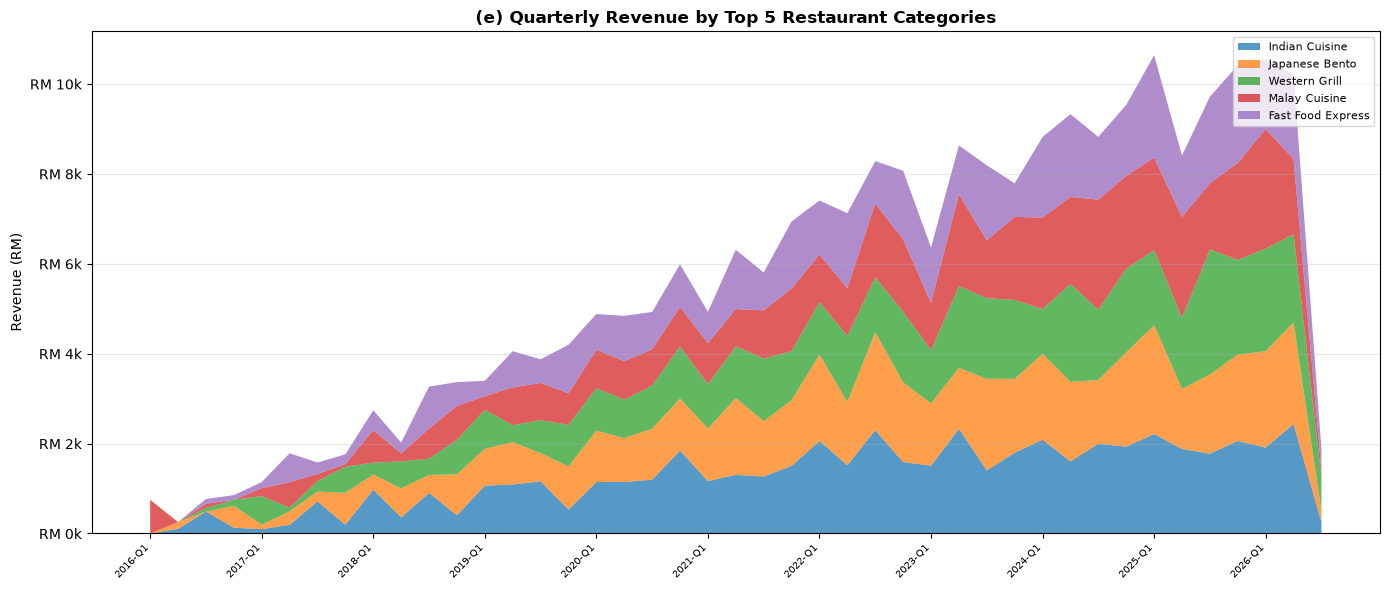

In [7]:
fig5, ax5 = plt.subplots(figsize=(14, 6))
cat_rev = df.groupby("category")["total_revenue"].sum()
top5_cats = cat_rev.nlargest(5).index.tolist()
grp5 = df[df["category"].isin(top5_cats)].groupby(
    ["yr_quarter", "category"])["total_revenue"].sum().unstack(fill_value=0)
grp5 = grp5[top5_cats]

ax5.stackplot(range(len(grp5)), [grp5[c] for c in top5_cats],
              labels=top5_cats, alpha=0.75)
step5 = max(1, len(grp5) // 10)
ax5.set_xticks(range(0, len(grp5), step5))
ax5.set_xticklabels(grp5.index[::step5], rotation=45, ha="right", fontsize=7)
ax5.set_ylabel("Revenue (RM)")
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'RM {x/1000:.0f}k'))
ax5.set_title(
    "(e) Quarterly Revenue by Top 5 Restaurant Categories",
    fontweight="bold"
)
ax5.legend(loc="upper right", fontsize=8)
ax5.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Combined dashboard (all 5 visualisations) and save to file

Saved: c:\Users\KTYJ\Documents\TARUMT\NEW ERA\WAREHOUSE\Data-warehouse\tjy\restaurant_performance_dashboard.png


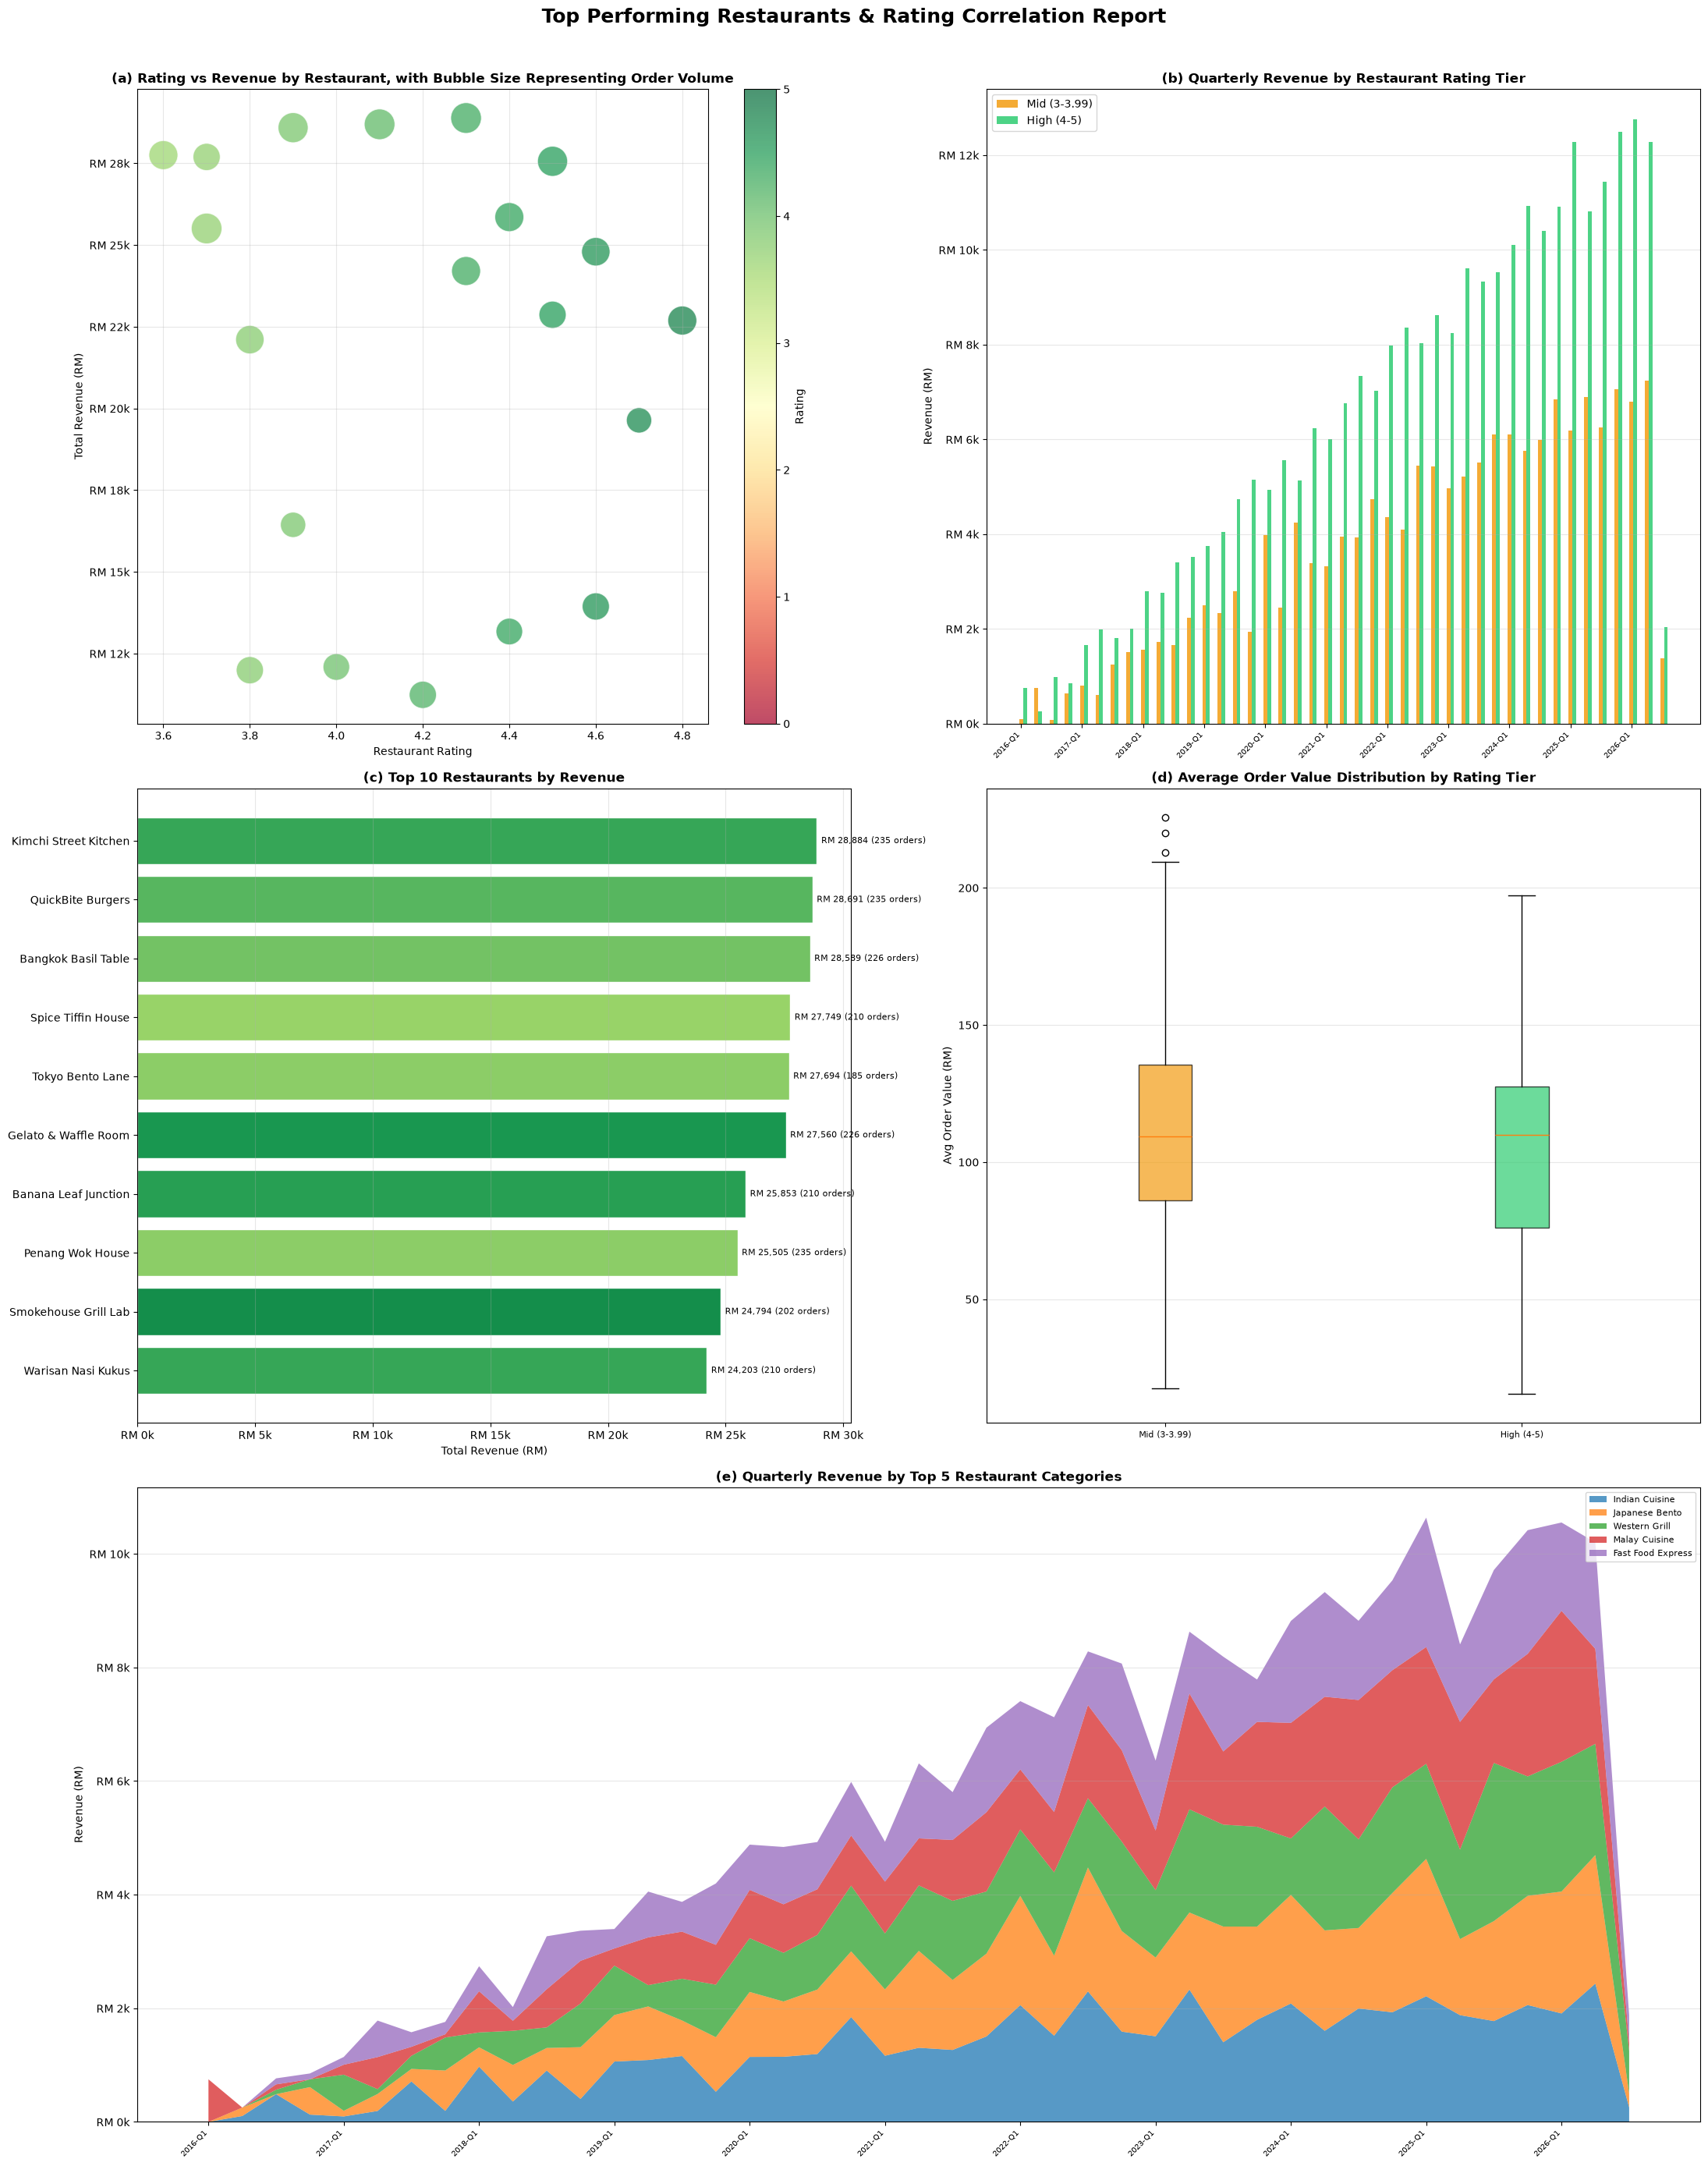

In [8]:
fig = plt.figure(figsize=(22, 28))
fig.suptitle("Top Performing Restaurants & Rating Correlation Report",
             fontsize=18, fontweight="bold", y=0.99)

# VIZ 1
ax1 = fig.add_subplot(3, 2, 1)
scatter = ax1.scatter(
    rest_agg["rating"], rest_agg["total_revenue"],
    s=bubble, c=rest_agg["rating"], cmap="RdYlGn",
    vmin=0, vmax=5, alpha=0.7, edgecolors="white", linewidths=0.8
)
plt.colorbar(scatter, ax=ax1, label="Rating")
ax1.set_xlabel("Restaurant Rating")
ax1.set_ylabel("Total Revenue (RM)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'RM {x/1000:.0f}k'))
ax1.set_title("(a) Rating vs Revenue by Restaurant, with Bubble Size Representing Order Volume", fontweight="bold")
ax1.grid(alpha=0.3)

# VIZ 2
ax2 = fig.add_subplot(3, 2, 2)
for i, tier in enumerate(["Low (0-2.99)", "Mid (3-3.99)", "High (4-5)"]):
    if tier in grp2.columns:
        ax2.bar(x + i * w, grp2[tier], w, label=tier, color=TIER_COLORS.get(tier, "grey"), alpha=0.85)
ax2.set_xticks(x[::step2] + w)
ax2.set_xticklabels([quarters[i] for i in range(0, len(quarters), step2)], rotation=45, ha="right", fontsize=7)
ax2.set_ylabel("Revenue (RM)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'RM {x/1000:.0f}k'))
ax2.set_title("(b) Quarterly Revenue by Restaurant Rating Tier", fontweight="bold")
ax2.legend()
ax2.grid(axis="y", alpha=0.3)

# VIZ 3
ax3 = fig.add_subplot(3, 2, 3)
bars = ax3.barh(top10["restaurant_name"], top10["total_revenue"], color=colors3, edgecolor="white")
ax3.set_xlabel("Total Revenue (RM)")
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'RM {x/1000:.0f}k'))
ax3.set_title("(c) Top 10 Restaurants by Revenue", fontweight="bold")
ax3.invert_yaxis()
ax3.grid(axis="x", alpha=0.3)
ax3.bar_label(bars, labels=labels, padding=4, fontsize=8)

# VIZ 4
ax4 = fig.add_subplot(3, 2, 4)
bp = ax4.boxplot(tier_data, patch_artist=True)
ax4.set_xticks(range(1, len(tiers_present) + 1))
ax4.set_xticklabels(tiers_present, fontsize=8)
for patch, tier in zip(bp["boxes"], tiers_present):
    patch.set_facecolor(TIER_COLORS.get(tier, "grey"))
    patch.set_alpha(0.7)
ax4.set_ylabel("Avg Order Value (RM)")
ax4.set_title("(d) Average Order Value Distribution by Rating Tier", fontweight="bold")
ax4.grid(axis="y", alpha=0.3)

# VIZ 5
ax5 = fig.add_subplot(3, 1, 3)
ax5.stackplot(range(len(grp5)), [grp5[c] for c in top5_cats], labels=top5_cats, alpha=0.75)
ax5.set_xticks(range(0, len(grp5), step5))
ax5.set_xticklabels(grp5.index[::step5], rotation=45, ha="right", fontsize=7)
ax5.set_ylabel("Revenue (RM)")
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'RM {x/1000:.0f}k'))
ax5.set_title("(e) Quarterly Revenue by Top 5 Restaurant Categories", fontweight="bold")
ax5.legend(loc="upper right", fontsize=8)
ax5.grid(axis="y", alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.98])
out = os.path.join(os.getcwd(), "restaurant_performance_dashboard.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
print(f"Saved: {out}")
plt.show()